In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("merged_df_raw.csv")
df.shape
df.head(5)



,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE,station_number,year_local,month_local,day_local,hour_local,...,max_gust_kmh,max_gust_quality,mslp_hpa,mslp_quality,station_level_pressure_hpa,station_level_pressure_quality,aws_flag,station_name,latitude,longitude
0,NSW1,2000-09-01 00:30:00,8117.23667,36.72,TRADE,66062.0,2000.0,9.0,1.0,1.0,...,NaN,NaN,1011.3,N,1006.5,N,1.0,SYDNEY (OBSERVATORY HILL),-33.8607,151.205
1,NSW1,2000-09-01 01:00:00,7799.70000,32.92,TRADE,66062.0,2000.0,9.0,1.0,2.0,...,NaN,NaN,1011.1,N,1006.3,N,1.0,SYDNEY (OBSERVATORY HILL),-33.8607,151.205
2,NSW1,2000-09-01 01:30:00,7453.99000,27.84,TRADE,66062.0,2000.0,9.0,1.0,2.0,...,NaN,NaN,1011.3,N,1006.5,N,1.0,SYDNEY (OBSERVATORY HILL),-33.8607,151.205
3,NSW1,2000-09-01 02:00:00,7095.55333,30.62,TRADE,66062.0,2000.0,9.0,1.0,3.0,...,NaN,NaN,1011.3,N,1006.5,N,1.0,SYDNEY (OBSERVATORY HILL),-33.8607,151.205
4,NSW1,2000-09-01 02:30:00,6786.22167,33.53,TRADE,66062.0,2000.0,9.0,1.0,3.0,...,NaN,NaN,1011.2,N,1006.4,N,1.0,SYDNEY (OBSERVATORY HILL),-33.8607,151.205


In [54]:
df = df.drop_duplicates(subset=["REGION", "SETTLEMENTDATE"], keep="first")

## remove duplicate rows, took the first entry of the duplicate. 

In [55]:
www = ["REGION", "SETTLEMENTDATE", "TOTALDEMAND", "air_temperature_c"]
sdf = df[www]
sdf.shape
sdf.head()

## select necessary columns that was relevant to research question

,REGION,SETTLEMENTDATE,TOTALDEMAND,air_temperature_c
0,NSW1,2000-09-01 00:30:00,8117.23667,13.7
1,NSW1,2000-09-01 01:00:00,7799.70000,13.6
2,NSW1,2000-09-01 01:30:00,7453.99000,13.4
3,NSW1,2000-09-01 02:00:00,7095.55333,13.5
4,NSW1,2000-09-01 02:30:00,6786.22167,13.6


In [56]:
sdf = sdf.dropna(subset=["air_temperature_c"])
sdf.info()

## drop missing values from air temperature, ignored the missing values from other columns that wre not needed for research question

<class 'pandas.core.frame.DataFrame'>
Index: 1647516 entries, 0 to 1658964
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   REGION             1647516 non-null  object 
 1   SETTLEMENTDATE     1647516 non-null  object 
 2   TOTALDEMAND        1647516 non-null  float64
 3   air_temperature_c  1647516 non-null  float64
dtypes: float64(2), object(2)
memory usage: 62.8+ MB


In [57]:
sdf["SETTLEMENTDATE"] = pd.to_datetime(sdf["SETTLEMENTDATE"])

sdf["date"] = sdf["SETTLEMENTDATE"].dt.date

daily = sdf.groupby(["REGION", "date"]).agg(
    temp_max=("air_temperature_c", "max"),
    temp_mean=("air_temperature_c", "mean"),
    demand_mean=("TOTALDEMAND", "mean"),
    demand_peak=("TOTALDEMAND", "max"),
).reset_index()

## create a new column with the daily summaries instead of half-hourly. Also groups by state and calculates summary statistics for each group.

daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values("date").reset_index(drop=True)

## converts back to date time for plotting later and sorts rows by date

daily.info()
daily.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34470 entries, 0 to 34469
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   REGION       34470 non-null  object        
 1   date         34470 non-null  datetime64[ns]
 2   temp_max     34470 non-null  float64       
 3   temp_mean    34470 non-null  float64       
 4   demand_mean  34470 non-null  float64       
 5   demand_peak  34470 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 1.6+ MB


,REGION,date,temp_max,temp_mean,demand_mean,demand_peak
0,NSW1,2000-01-01,20.8,18.155319,5720.094291,6763.57000
1,QLD1,2000-01-01,26.8,23.246809,3969.868794,4608.53000
2,VIC1,2000-01-01,21.1,16.770213,3844.394539,4599.70167
3,SA1,2000-01-01,19.1,15.273913,1024.572863,1375.14833
4,SA1,2000-01-02,27.0,20.137500,1087.140556,1264.26000


In [58]:
1650156/48

34378.25

In [61]:
hot_threshold = daily["temp_max"].quantile(0.75)
cold_threshold = daily["temp_max"].quantile(0.25)
daily["is_hot"] = daily["temp_max"] >= hot_threshold
daily["is_cold"] = daily["temp_max"] <= cold_threshold

## definning thresholds for hot and cold days. Using top 25% of the hottest and coldest days for each state.

i needed a way of measuring how long a streak had lasted in order to answer my research question so i created a counter that tracks how many consecutive cold or hot days occured. so for each row counter increased by one if day was classified as hot or cold otherwise it went back to 0. 

In [62]:
daily = daily.sort_values(["REGION", "date"]).reset_index(drop=True)
## sorts rows in chronological order of states then date

consecutive_hot_days = []
consecutive_cold_days = []

## create empty lists for consecutive hot and cold days

current_region = None
hot_count = 0
cold_count = 0

for i in range(len(daily)):
    region = daily.loc[i, "REGION"]

## reset counters whenever we move to a new state so that the consecutive days dont carry over to the next state count
    
    if region != current_region:
        current_region = region
        hot_count = 0
        cold_count = 0

## hot days
    if daily.loc[i, "is_hot"]:
        hot_count += 1
    else:
        hot_count = 0

## cold days
    if daily.loc[i, "is_cold"]:
        cold_count += 1
    else:
        cold_count = 0

    consecutive_hot_days.append(hot_count)
    consecutive_cold_days.append(cold_count)

daily["consecutive_hot_days"] = consecutive_hot_days
daily["consecutive_cold_days"] = consecutive_cold_days


EDA

In [63]:
import matplotlib.pyplot as plt

import seaborn as sns

                 count         mean       median
consecutivedays                                 
Day 1             2586  4934.192527  5511.238316
Day 2             1463  4897.180585  5574.255833
Day 3              884  5042.818526  5704.182083
Day 4+            3762  5368.469399  5948.578643


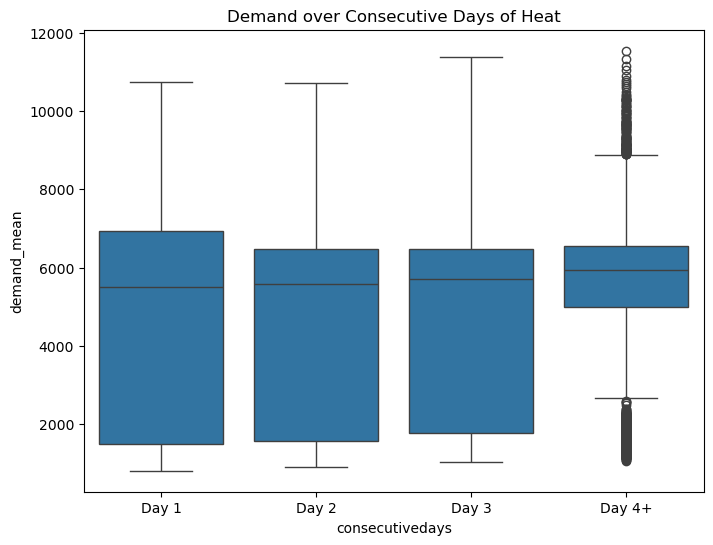

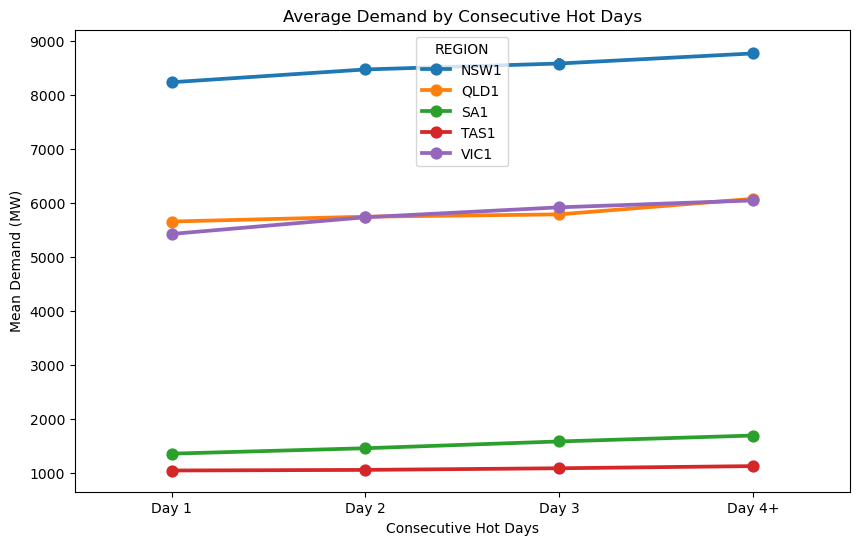

In [112]:
hot_days = daily[daily["consecutive_hot_days"] > 0].copy()

hot_days["consecutivedays"] = "Day 4+"
hot_days.loc[hot_days["consecutive_hot_days"] == 1, "consecutivedays"] = "Day 1"
hot_days.loc[hot_days["consecutive_hot_days"] == 2, "consecutivedays"] = "Day 2"
hot_days.loc[hot_days["consecutive_hot_days"] == 3, "consecutivedays"] = "Day 3"

## turn the counter numbers into categories for plotting

day_order = ["Day 1", "Day 2", "Day 3", "Day 4+"]

plt.figure(figsize=(8, 6))
sns.boxplot(data=hot_days, x="consecutivedays", y="demand_mean", order=day_order)
plt.title("Demand over Consecutive Days of Heat")

## summary table
print(hot_days.groupby("consecutivedays")["demand_mean"].agg(["count", "mean", "median"]).reindex(day_order))


## line
plt.figure(figsize=(10, 6))
sns.pointplot(data=hot_days, x="consecutivedays", y="demand_mean", hue="REGION", order=day_order, errorbar="se")
plt.title("Average Demand by Consecutive Hot Days")
plt.xlabel("Consecutive Hot Days")
plt.ylabel("Mean Demand (MW)")
plt.show()

The boxplot of demand across consecutive hot days shows a clearer, more consistent pattern in support of the research question: median demand rises steadily from Day 1 5511 to Day 4+ 5949. 

in the line graph there is an increase across the days

                 count         mean       median
consecutivedays                                 
Day 1             1968  3959.968421  1626.494479
Day 2             1154  3752.795136  1581.538177
Day 3              754  3632.768522  1586.255764
Day 4+            4808  3214.548392  1577.991667


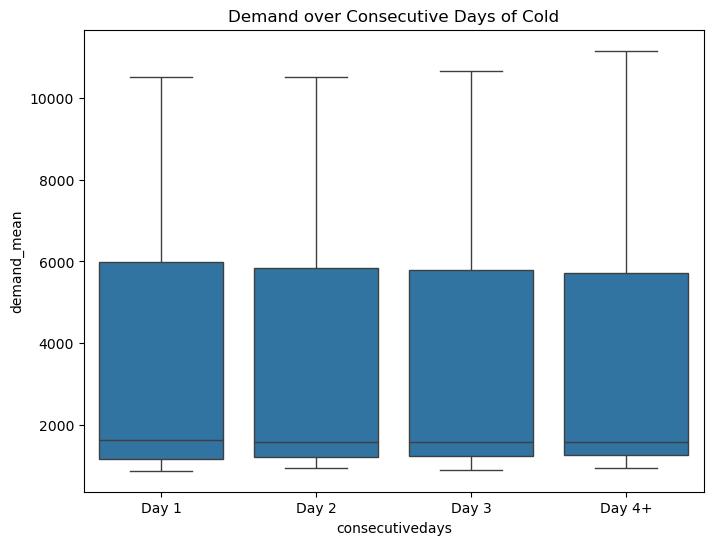

In [81]:
cold_days = daily[daily["consecutive_cold_days"] > 0].copy()

cold_days["consecutivedays"] = "Day 4+"
cold_days.loc[cold_days["consecutive_cold_days"] == 1, "consecutivedays"] = "Day 1"
cold_days.loc[cold_days["consecutive_cold_days"] == 2, "consecutivedays"] = "Day 2"
cold_days.loc[cold_days["consecutive_cold_days"] == 3, "consecutivedays"] = "Day 3"

streak_order = ["Day 1", "Day 2", "Day 3", "Day 4+"]

plt.figure(figsize=(8, 6))
sns.boxplot(data=cold_days, x="consecutivedays", y="demand_mean", order=day_order)
plt.title("Demand over Consecutive Days of Cold")

## summary table
print(cold_days.groupby("consecutivedays")["demand_mean"].agg(["count", "mean", "median"]).reindex(day_order))

mean demand actually declines from Day 1 3960 to Day 4+ 3215, while the median stays essentially flat $1580–1626 across all streak lengths. 



however, this chart combines all five states together, and the large gap between the mean and median values indicates the distribution is heavily skewed by cross-state differences in baseline demand (e.g. NSW's much higher demand pulling the mean upward relative to lower-demand states like SA and TAS).

a boxplot doesnt control for the temperature itself on each day, a Day 3+ reading might include hotter days on average than Day 1, which would also possibly make demand look higher for a reason unrelated to the build up of hot days. 

Text(0.5, 1.0, 'average Demand by Consecutive Cold Days')

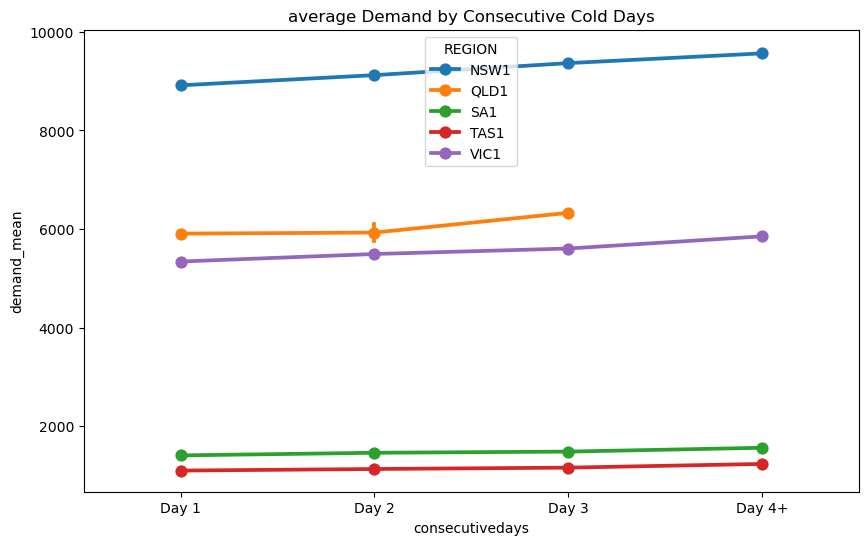

In [106]:
summary = all_states.groupby(["REGION", "consecutivedays"])["demand_mean"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.pointplot(data=all_states, x="consecutivedays", y="demand_mean", hue="REGION", order=streak_order, errorbar="se")
plt.title("average Demand by Consecutive Cold Days")



the line graph fixes the state problem from the box plots

but still doesnt fix the issue of same day temperature increase rather than build up

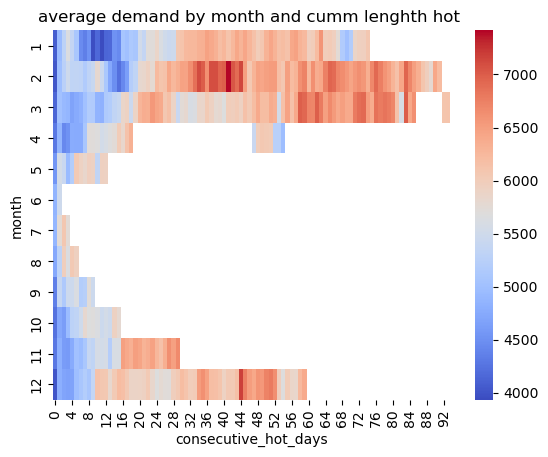

Text(50.722222222222214, 0.5, 'month')

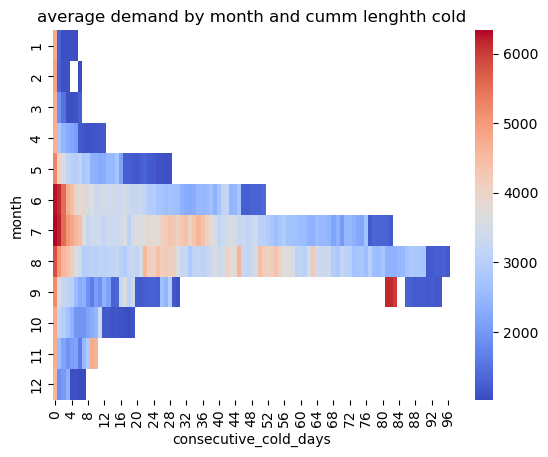

In [116]:
pivot = daily.pivot_table(values="demand_mean", index=daily["date"].dt.month, columns="consecutive_hot_days", aggfunc="mean")
sns.heatmap(pivot, cmap="coolwarm", annot=False)
plt.title("average demand by month and cumm lenghth hot ")
plt.ylabel("month")
plt.show()


pivot = daily.pivot_table(values="demand_mean", index=daily["date"].dt.month, columns="consecutive_cold_days", aggfunc="mean")
sns.heatmap(pivot, cmap="coolwarm", annot=False)
plt.title("average demand by month and cumm lenghth cold")
plt.ylabel("month")

- the increase of demand might be because of temperature itself on each day, since a Day 3+ reading might include hotter days on average than Day 1 which could be reason to a higher demand
- weekday or weekend being included in the streak could also effect demand

next build the rergression model:

demand_mean = temp_max + consecutive_hot_days + consecutive_cold_days + region

which will control the temp incr issue

also mayb compare hot and cold, is the build up of one have a bigger effect than the other